Question 1a

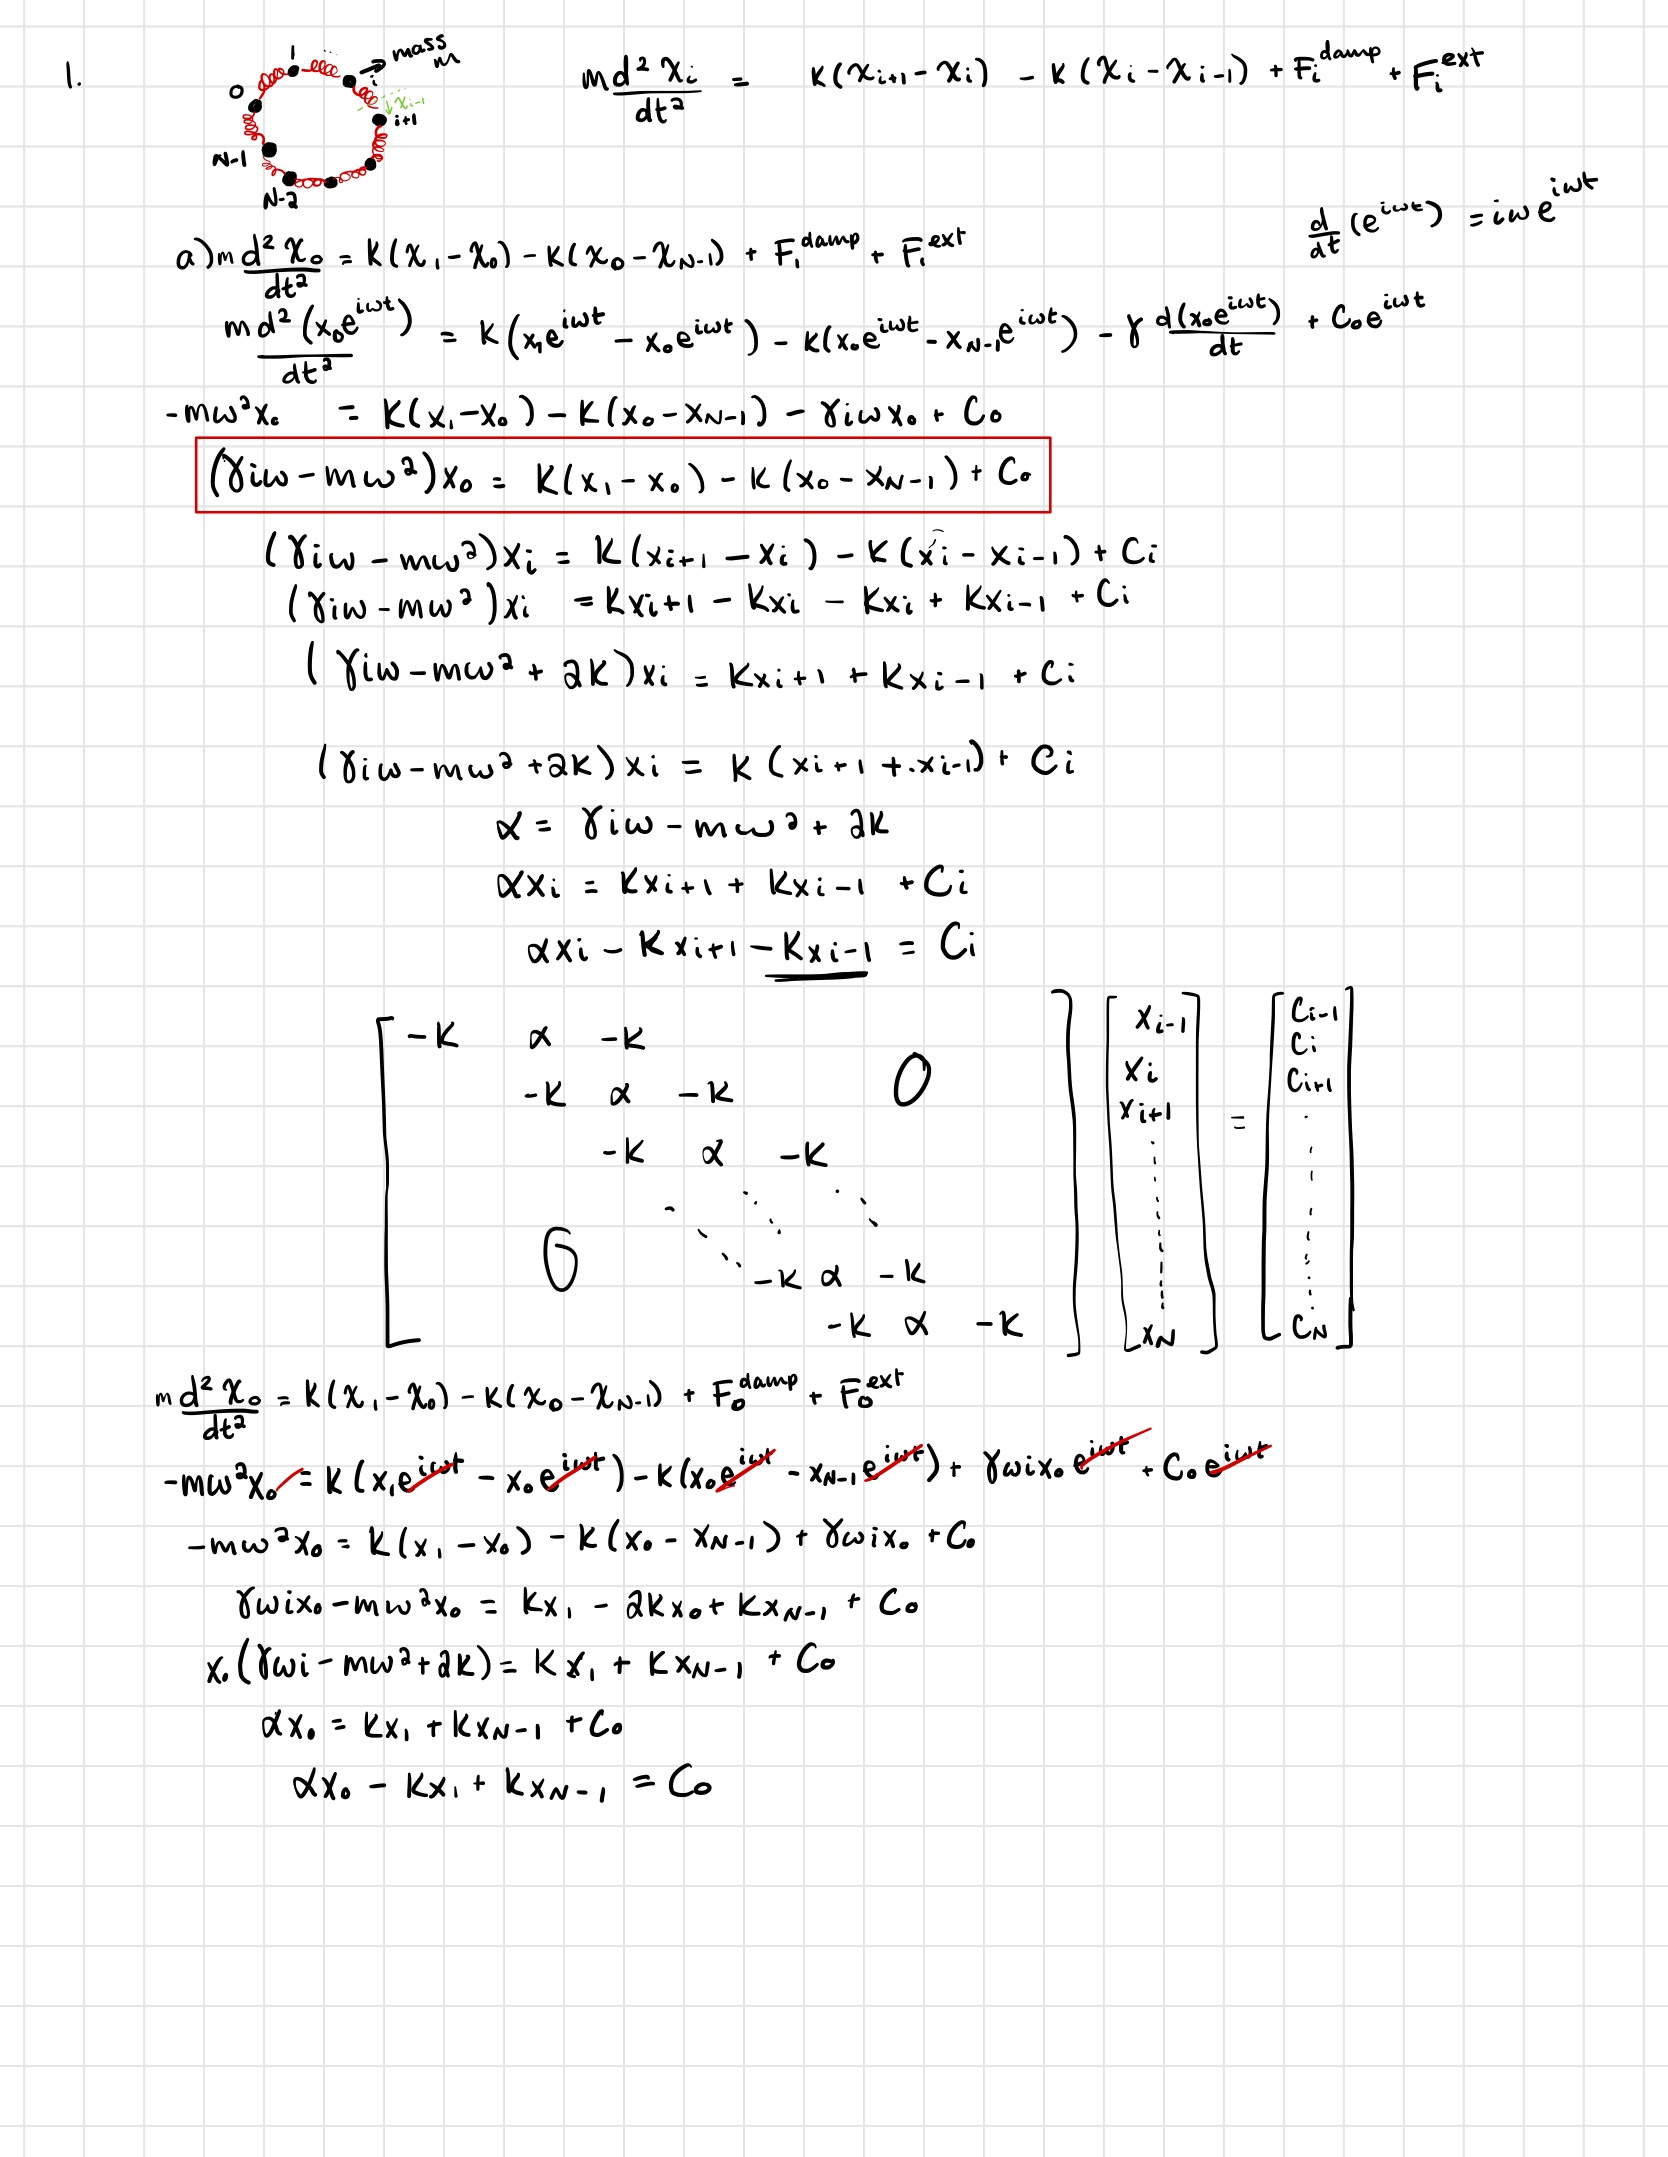

Question 1b

In [217]:
import numpy as np
from numpy import array, empty, zeros, copy
import matplotlib.pyplot as plt

In [218]:
def PartialPivot(A, v, m):

    from numpy import copy
    
    N = len(v)
    #copy the A and v matrices
    A_orig = copy(A)
    v_orig = copy(v)

    #get the pivot row and the max value of that row
    pivot_row = m
    max_ele = abs(A[m, m])

    for k in range(m+1, N):
        if abs(A[k, m]) > max_ele:
            pivot_row = k
            max_ele = abs(A[k, m])

    if pivot_row != m:
        #pivot the row
        A[m, :] = A_orig[pivot_row, :]
        v[m] = v_orig[pivot_row]
        A[pivot_row, :] = A_orig[m, :]
        v[pivot_row] = v_orig[m]
        
    return A, v



In [219]:
# Gaussian elimination
def ge(A,v):
    
    N = len(v)   
    
    for m in range(N):
        
        # Call pivoting function
        A,v = PartialPivot(A,v,m)
        
        # Divide by the diagonal element
        div = A[m,m]
        A[m,:] /= div
        v[m] /= div

        # subtract from the lower rows
        for i in range(m+1,N):
            mult = A[i,m]
            A[i,:] -= mult*A[m,:]
            v[i] -= mult*v[m]

    return A,v  

In [220]:
def backsub(A, v):

    n = len(v)
    x = empty(n, complex)

    #get the values for each x
    for i in range(n-1, -1, -1):
        x[i] = v[i]
        for j in range(i+1, n):
            x[i] -= A[i, j]*x[j]

    return x

Question 1c

In [221]:
#variables from 1a
N = 13
m = 1
k = 5
gamma = 1.5
omega = 2
C = 1

#calculate alpha
alpha = (gamma * omega * complex(0, 1) - (m * (omega ** 2)) + (2 * k))

#initialize matrix
A = zeros([N, N], complex)

#fill in the calculated diagonal elements from 1a
for i in range(N):
    A[i, i] = alpha
    if i > 0:
        A[i, i-1] = -k
    if i < N-1:
        A[i, i+1] = -k

#create the v matrix
v = zeros(N,complex)
v[(N-1) // 2] = C

# Look at A (3x3 matrix) and v
print("\nA matrix before Gaussian Elimination:\n",A[0:3, 0:3],"\n\nv vector:\n",v,"\n")


A matrix before Gaussian Elimination:
 [[ 6.+3.j -5.+0.j  0.+0.j]
 [-5.+0.j  6.+3.j -5.+0.j]
 [ 0.+0.j -5.+0.j  6.+3.j]] 

v vector:
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j] 



In [222]:
# Call GE function
A_orig = copy(A)
v_orig = copy(v)
A_new,v_new = ge(A_orig, v_orig)

# Look at A and v
print("A matrix after Gaussian Elimination\n",A_new[0:3, 0:3],"\n\nNew v vector\n",v_new)

x = backsub(A_new, v_new)

print("Vector x is:\n", x)

A matrix after Gaussian Elimination
 [[ 1.        +0.j         -0.66666667+0.33333333j  0.        +0.j        ]
 [ 0.        +0.j          1.        +0.j         -0.46153846+0.80769231j]
 [ 0.        +0.j         -0.        +0.j          1.        +0.j        ]] 

New v vector
 [ 0.        +0.j          0.        +0.j          0.        +0.j
  0.        +0.j          0.        +0.j          0.        +0.j
  0.07910903-0.11451294j -0.03493187-0.09143218j -0.06676212-0.01578288j
 -0.03548356+0.03235319j  0.00468673+0.03332653j  0.02114036+0.01045378j
  0.01440007-0.00810103j]
Vector x is:
 [ 0.01440007-0.00810103j  0.0221407 -0.00108119j  0.01281749+0.02008802j
 -0.01881253+0.03287731j -0.0551189 +0.00807723j -0.0521765 -0.05625597j
  0.02626069-0.1068903j  -0.0521765 -0.05625597j -0.0551189 +0.00807723j
 -0.01881253+0.03287731j  0.01281749+0.02008802j  0.0221407 -0.00108119j
  0.01440007-0.00810103j]


The magnitudes are: 
 [0.01652237 0.02216708 0.0238289  0.03787913 0.05570759 0.07672758
 0.11006888 0.07672758 0.05570759 0.03787913 0.0238289  0.02216708
 0.01652237]

The angles are:  [-0.51244165 -0.04879404  1.00285617  2.09052684  2.99608635 -2.31858998
 -1.3298887  -2.31858998  2.99608635  2.09052684  1.00285617 -0.04879404
 -0.51244165]


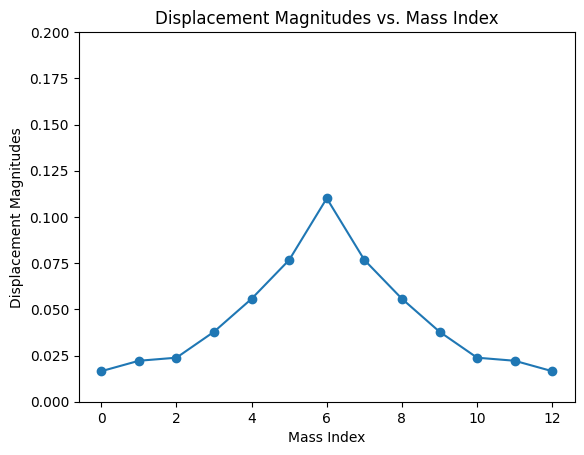

In [223]:
#get the magnitudes and angles
magnitudes = abs(x)
theta = np.angle(x)

print("The magnitudes are: \n", magnitudes)
print("\nThe angles are: ", theta)

#get the range of magnitudes to plot
indices = np.arange(len(magnitudes))
mask = (magnitudes >= 0) & (magnitudes <= 0.2)

#plot the magnitudes between 0 and 0.2
plt.plot(indices[mask], magnitudes[mask], marker='o', linestyle='-')
plt.ylim(0, 0.2)
plt.xlabel("Mass Index")
plt.ylabel("Displacement Magnitudes")
plt.title("Displacement Magnitudes vs. Mass Index")
plt.show()
    

Question 1d

In [224]:
#copy from part c
N = 13
m = 1
k = 5
gamma = 1.5
omega = 2
C = 1
alpha = (gamma * omega * complex(0, 1) - (m * (omega ** 2)) + (2 * k))

#set the first row to the updated values
A_d = zeros([N, N], complex)
A_d[0,:] = 0
A_d[0,0] = 1
for i in range(1,N):
    A_d[i, i] = alpha
    if i > 0:
        A_d[i, i-1] = -k
    if i < N-1:
        A_d[i, i+1] = -k

v_d = zeros(N,complex)
v_d[(N-1) // 2] = C
v_d[0] = 0


# Look at A (3x3 matrix) and v
print("\nA matrix before Gaussian Elimination:\n",A_d[0:3, 0:3],"\n\nv vector:\n",v_d,"\n")


A matrix before Gaussian Elimination:
 [[ 1.+0.j  0.+0.j  0.+0.j]
 [-5.+0.j  6.+3.j -5.+0.j]
 [ 0.+0.j -5.+0.j  6.+3.j]] 

v vector:
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j] 



A matrix now: 
 [[ 1. -0.j  -1.2-0.6j  1. -0.j ]
 [-0. -0.j   1. -0.j  -1.2-0.6j]
 [-0. -0.j  -0. -0.j   1. -0.j ]] 

and v vector now: 
 [-0.        -0.j         -0.        -0.j         -0.        -0.j
 -0.        -0.j         -0.        -0.j         -0.2       -0.j
  0.07664821-0.11645711j -0.0363614 -0.08995011j -0.06662696-0.01470024j
 -0.03477613+0.03282597j  0.00524004+0.03306064j  0.0212017 +0.01004308j
  0.01418894-0.00830341j]

Solution of vector x is:
 [ 0.        -0.j          0.02114036+0.01045378j  0.01909616+0.02522876j
 -0.01336222+0.03127842j -0.05389788+0.00428802j -0.05388804-0.05847153j
  0.02431514-0.10678668j -0.05286178-0.0550834j  -0.05469924+0.00896954j
 -0.01815903+0.0330273j   0.01309202+0.0197678j   0.02200877-0.00145072j
  0.01418894-0.00830341j]

The magnitudes are: 
 [0.         0.02358382 0.03164101 0.03401307 0.05406818 0.07951629
 0.10951996 0.07634493 0.05542977 0.03769022 0.02371006 0.02205653
 0.01643997]

The angles are: 
 [-0.70862627  0.45923324  

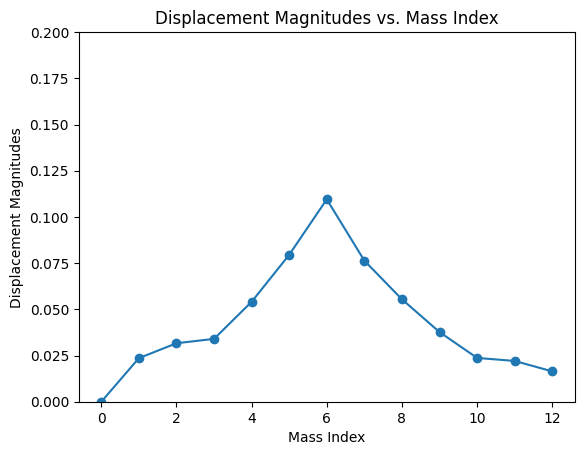

In [225]:
# Call GE function
A_org = copy(A_d)
v_org = copy(v_d)
A_new2,v_new2 = ge(A_org, v_org)

# Look at A and v
print("A matrix now: \n",A_new2[0:3, 0:3],"\n\nand v vector now: \n",v_new2)

x2 = backsub(A_new2, v_new2)

print("\nSolution of vector x is:\n", x2)

magnitudes2 = abs(x2)
theta2 = np.angle(x2)

print("\nThe magnitudes are: \n", magnitudes2)
print("\nThe angles are: \n", theta2)

indices2 = np.arange(len(magnitudes2))
mask2 = (magnitudes2 >= 0) & (magnitudes2 <= 0.2)


plt.plot(indices2[mask2], magnitudes2[mask2], marker='o', linestyle='-')
plt.ylim(0, 0.2)
plt.xlabel("Mass Index")
plt.ylabel("Displacement Magnitudes")
plt.title("Displacement Magnitudes vs. Mass Index")
plt.show()

Question 2a

In [226]:
#LU Decomposition function
def LUdecomp(A):
    n = len(A)
    L = np.eye(n) #identity
    U = copy(A)

    #get U and L matrices
    for i in range(n):
        for j in range(i+1, n):
            factor = U[j, i] / U[i, i]
            L[j, i] = factor
            U[j, :] -= factor * U[i, :]
    
    return L, U

Question 2b

In [ ]:
A = array([[8, 2, 1, 3],
     [3, 7, 2, 1],
     [1, 2, 3, 5],
     [2, 1, 3, 5]], float)

# get L and U matrices
L, U = LUdecomp(A)

print("\nL: ", L)
print("\n U: ", U)

#verify these give A
A_show = np.matmul(L, U)

print("\n A: ", A_show)



L:  [[1.         0.         0.         0.        ]
 [0.375      1.         0.         0.        ]
 [0.125      0.28       1.         0.        ]
 [0.25       0.08       1.08264463 1.        ]]

 U:  [[ 8.          2.          1.          3.        ]
 [ 0.          6.25        1.625      -0.125     ]
 [ 0.         -0.          2.42        4.66      ]
 [ 0.          0.         -0.         -0.78512397]]

 A:  [[8. 2. 1. 3.]
 [3. 7. 2. 1.]
 [1. 2. 3. 5.]
 [2. 1. 3. 5.]]


Question 2c

In [ ]:
#get y vector from L and v
def backsub_Lower(L, v):
    n = len(v)
    y = empty(n, float)

    for i in range(n):
        y[i] = v[i]
        for j in range(i):
            y[i] -= L[i, j]*y[j]

    return y

In [ ]:
#get x vector from U and y
def backsub_Upper(U, y):
    n = len(y)
    x = empty(n, float)

    for i in range(n-1, -1, -1):
        x[i] = y[i]
        for j in range(i+1, n):
            x[i] -= U[i, j]*x[j]
        x[i] /= U[i, i]

    return x

Question 2d

In [ ]:
#get x and y vectors
v_2d = array([6, 5, 7, 4], float)

y = backsub_Lower(L, v_2d)
print("\n y: ", y)
x = backsub_Upper(U, y)

print("\nx: ", x)




 y:  [ 6.          2.75        5.48       -3.65289256]

x:  [-0.72631579  2.27368421 -6.69473684  4.65263158]


Question 2e

In [ ]:
# find the inverse of A
N = len(A_show)
A_inv = np.zeros_like(A_show, float)

for i in range(N):
    elem_i = np.zeros(N)
    elem_i[i] = 1

    y_new = backsub_Lower(L, elem_i)
    x_new = backsub_Upper(U, y_new)

    A_inv[:, i] = x_new

print("A^-1: \n", A_inv)

A^-1: 
 [[ 0.07368421  0.04210526 -0.38947368  0.33684211]
 [ 0.07368421  0.04210526  0.61052632 -0.66315789]
 [-0.49473684  0.43157895 -2.24210526  2.45263158]
 [ 0.25263158 -0.28421053  1.37894737 -1.27368421]]


Question 3a

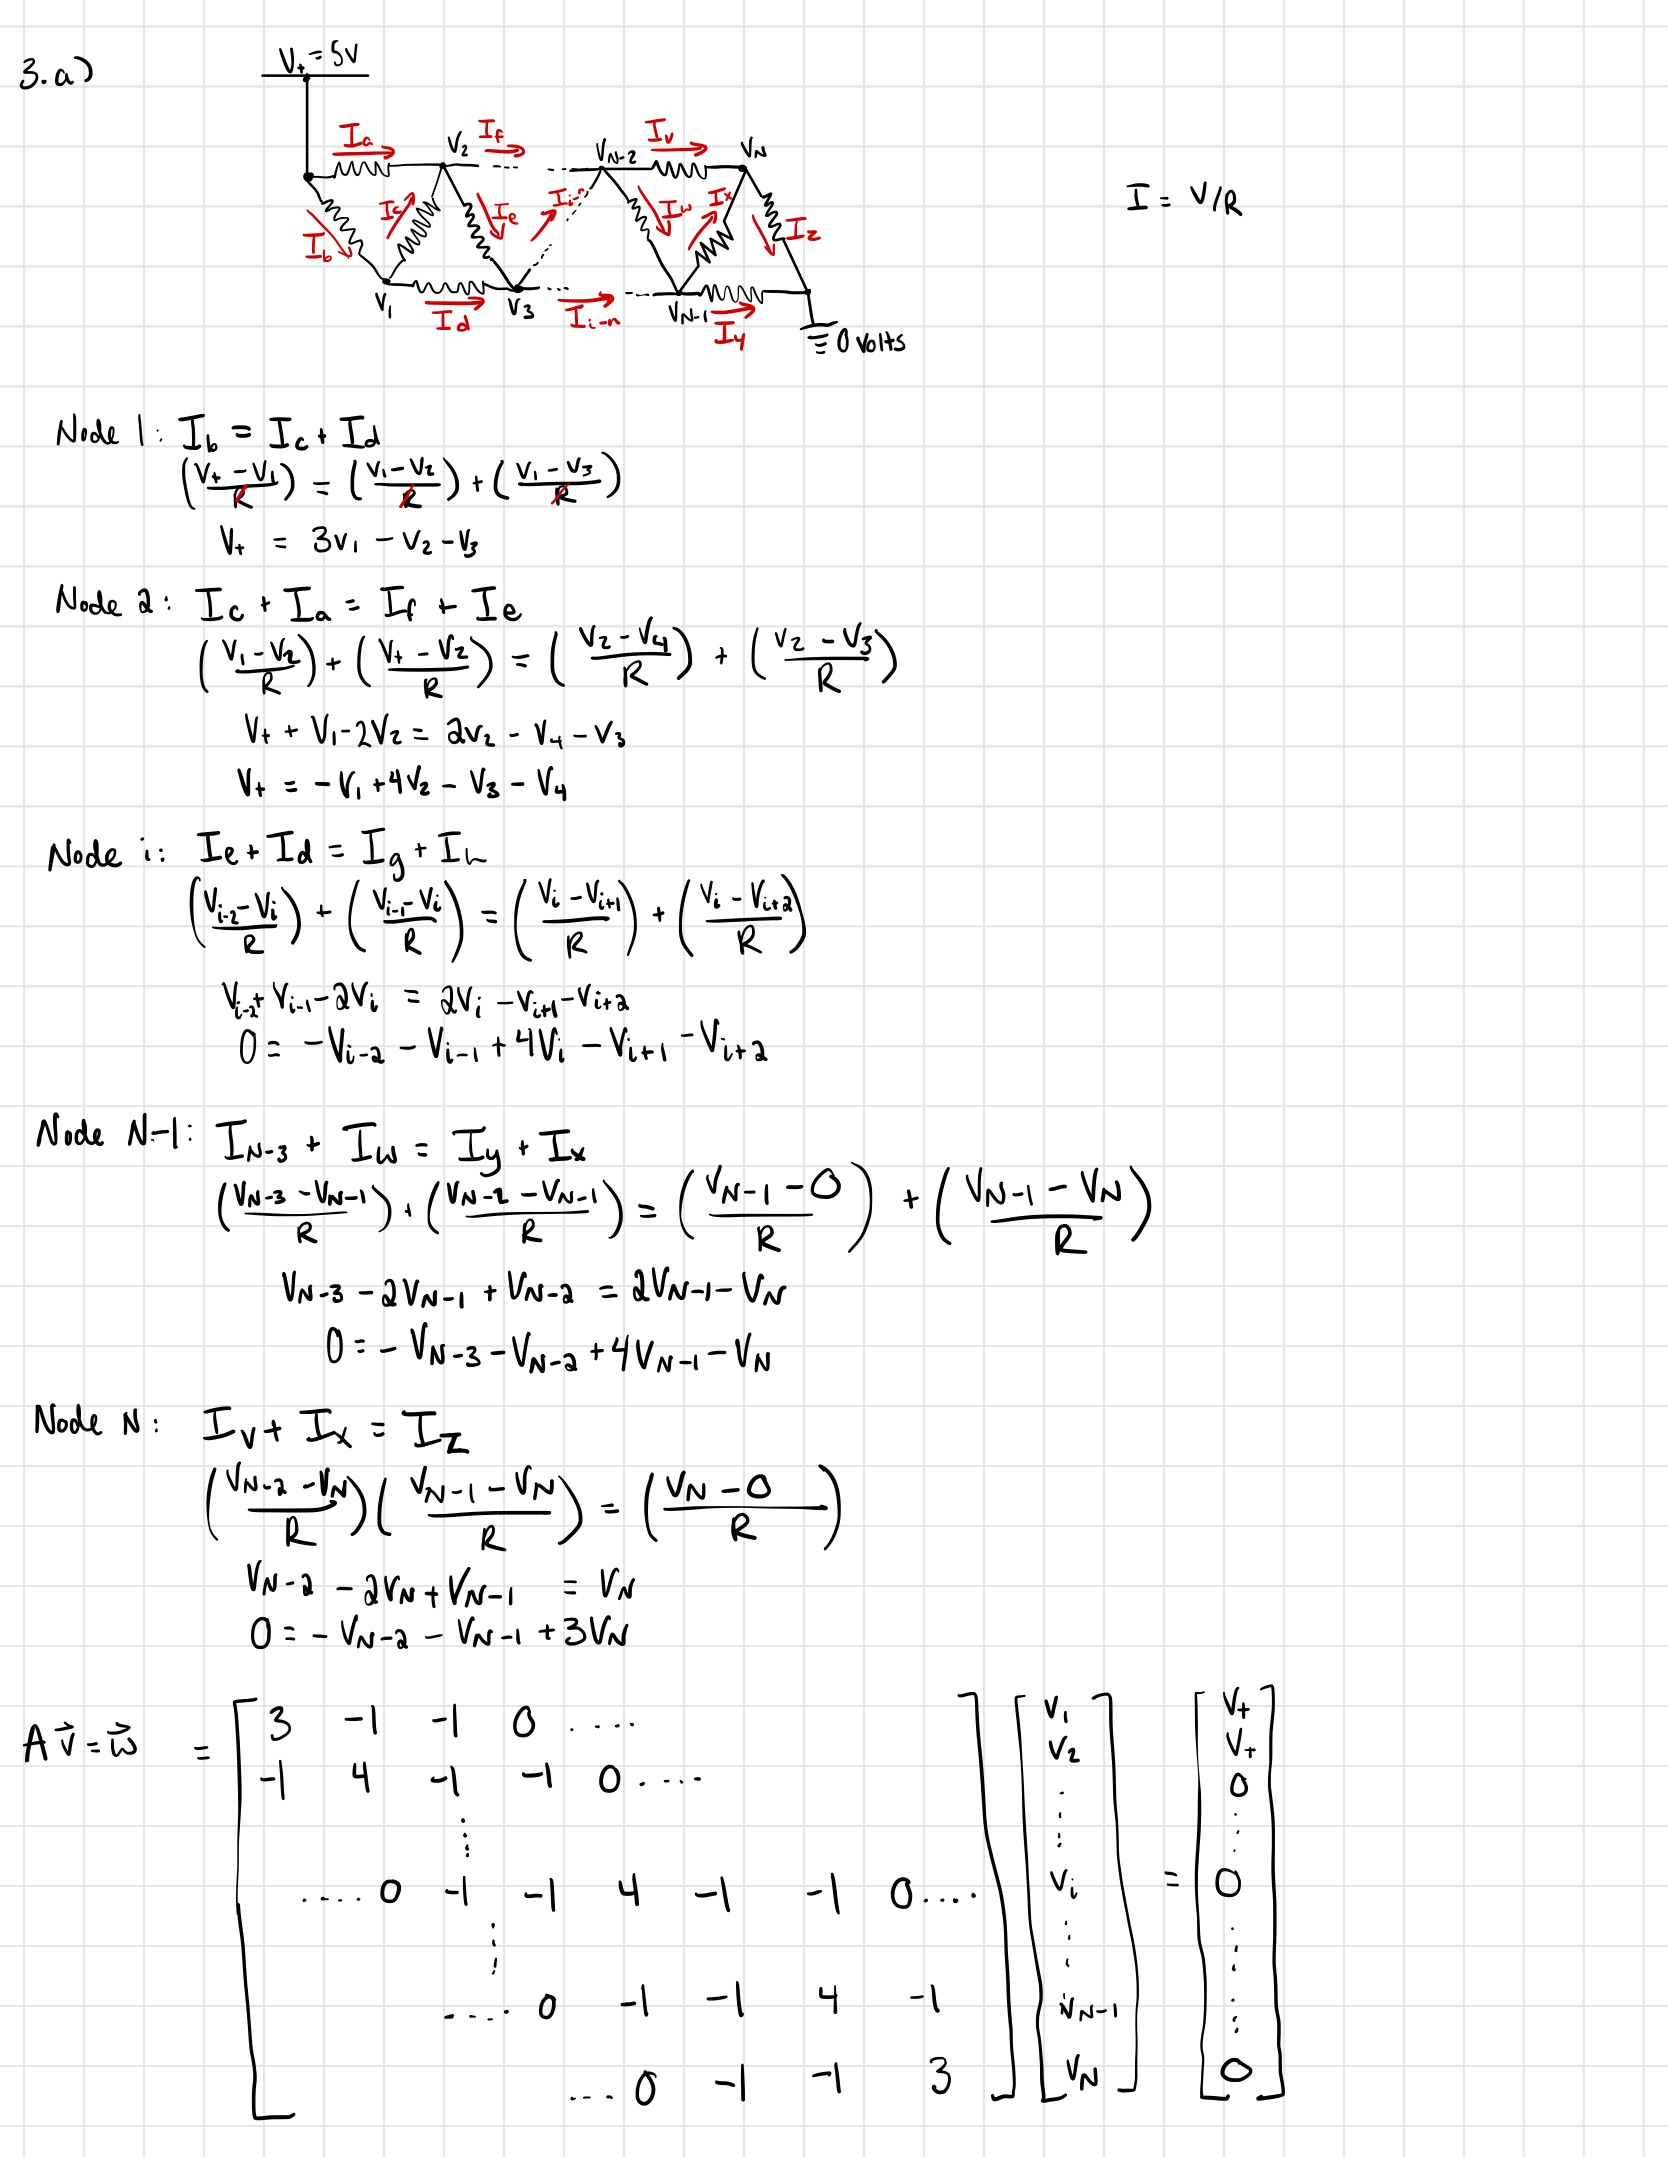

Question 3b

In [232]:
from numpy.linalg import solve

#set up the 6x6 matrix
N_3 = 6
Vp = 5

A_3 = np.zeros((N_3, N_3))

v_3 = np.zeros(N_3)

for i in range(N_3):
    A_3[i, i] = 4

A_3[0, 0] = A_3[-1, -1] = 3

for i in range(N_3 - 1):
    A_3[i, i+1] = A_3[i+1, i] = -1

for i in range(N_3 - 2):
    A_3[i, i+2] = A_3[i+2, i] = -1

v_3[0] = Vp
v_3[1] = Vp

#solve for the voltages
sol = solve(A_3, v_3)


print("\nThe A matrix is: \n", A_3)
print("Values of Vi when N=6 are: \n", sol)




The A matrix is: 
 [[ 3. -1. -1.  0.  0.  0.]
 [-1.  4. -1. -1.  0.  0.]
 [-1. -1.  4. -1. -1.  0.]
 [ 0. -1. -1.  4. -1. -1.]
 [ 0.  0. -1. -1.  4. -1.]
 [ 0.  0.  0. -1. -1.  3.]]
Values of Vi when N=6 are: 
 [3.7254902  3.43137255 2.74509804 2.25490196 1.56862745 1.2745098 ]


Question 3c

In [233]:
from banded import banded

#set up the matrix
N4 = 10000
m = 2

A_band = np.zeros((2*m+1, N4))

A_band[2, :] = 4
A_band[2, 0] = A_band[2, -1] = 3

A_band[1, 1:] = -1
A_band[3, :-1] = -1

A_band[0, 2:] = -1
A_band[4, :-2] = -1

#set up the w matrix
w = np.zeros(N4)
w[0] = Vp
w[1] = Vp

#solve using banded function
sol2 = banded(A_band, w, m, m)

print("The solution for the first 10 voltages with a banded A is: \n", sol2[0:10])
print("\nThe last 10 values are: \n", sol2[9990:N4])


The solution for the first 10 voltages with a banded A is: 
 [4.99888228 4.99861842 4.99802841 4.99756299 4.99704997 4.99655514
 4.99605336 4.99555423 4.99505409 4.99455433]

The last 10 values are: 
 [0.00544567 0.00494591 0.00444577 0.00394664 0.00344486 0.00295003
 0.00243701 0.00197159 0.00138158 0.00111772]
